Visualization of the success of the derived features (FE), the rationality of WoE/IV filtering, and the "Importance" (Gain/Shap) scores assigned to these features by the models.

In [123]:
import sys
import os
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

sys.path.append(os.path.abspath("../scripts"))

try:
    import config
    importlib.reload(config)
    # Added STAGE3_OUT to read the exploded data
    from config import STAGE1_OUT, STAGE3_OUT, STAGE4_OUT, VAL_SPLIT_DATE

    import data_loader
    importlib.reload(data_loader)

    import feature_engineering
    importlib.reload(feature_engineering)

    from utils import validation
    importlib.reload(validation)

    from utils import metrics
    importlib.reload(metrics)
    
    # Critical module for Stage 4
    from utils import statistical_tests
    importlib.reload(statistical_tests)

    import utils.plotting as plotting
    importlib.reload(plotting)
    plotting.set_style()

    print("Success: All modules and atomic functions reloaded.")
except Exception as e:
    print(f"Error during manual reload: {e}")

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

Success: All modules and atomic functions reloaded.


# **STAGE 3**

In [44]:
sub_train = pd.read_parquet(STAGE1_OUT / "train_base.parquet")
sub_val = pd.read_parquet(STAGE1_OUT / "val_base.parquet")
test_fe = pd.read_parquet(STAGE1_OUT / "test_base.parquet")

print(f"Initial Shapes -> Train: {sub_train.shape}, Val: {sub_val.shape}, Test: {test_fe.shape}")
display(sub_train.head(3))

Initial Shapes -> Train: (179080, 40), Val: (20920, 40), Test: (80000, 39)


,appointment_id,patient_id,clinic_id,specialty,appointment_datetime,booking_datetime,lead_time_hours,appointment_dow,appointment_hour,is_weekend,...,area_id,specialty_clinic,clinic_lat,clinic_lon,capacity_daily,base_wait_mins_est,open_on_saturday,sms_policy_prob,is_cold_start_clinic,sms_is_missing
0,2,17714,1,gynecology,2025-04-07 12:15:00,2025-03-28 22:26:39,229.805649,0,12,0,...,5,gynecology,39.950367,32.866608,89,22.465481,0,0.419637,0,0
1,4,4986,19,orthopedics,2025-07-17 16:45:00,2025-07-15 03:15:37,61.489704,3,16,0,...,119,orthopedics,39.845600,32.841854,81,27.688885,0,0.484473,0,1
2,5,1874,18,cardiology,2025-04-22 10:30:00,2025-03-22 23:56:40,730.555481,1,10,0,...,5,cardiology,40.103737,32.834515,81,30.246033,1,0.641033,0,1


In [45]:
# Check for missing values before FE
data_loader.check_missing_values(sub_train, "Sub-Train Base")
data_loader.check_missing_values(test_fe, "Test Base")

# Technical Note: age_bucket fails if age=0 is not handled or NaNs exist.
print(f"Unique age values (min/max): {sub_train['age'].min()} / {sub_train['age'].max()}")

Missing values found in Sub-Train Base:
                Missing Values  % of Total Values
sms_lead_hours           11581           6.466942
Missing values found in Test Base:
                Missing Values  % of Total Values
sms_lead_hours            5199            6.49875
Unique age values (min/max): 0 / 90


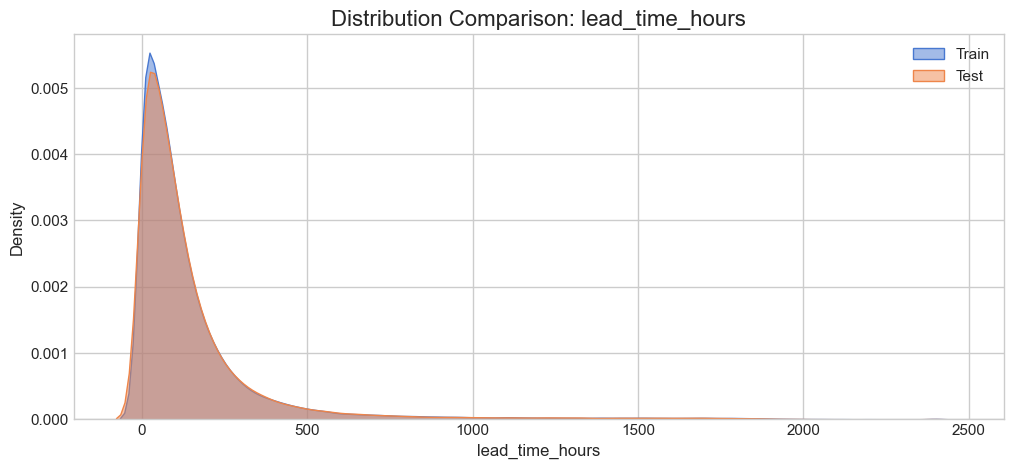

In [46]:
plotting.plot_distribution_comparison(sub_train, test_fe, 'lead_time_hours')

In [47]:
for df in [sub_train, sub_val, test_fe]:
    df = feature_engineering.create_temporal_features(df)

print(f"Post-Temporal Shape: {sub_train.shape}")
print("New temporal columns:", [c for c in sub_train.columns if 'sin' in c or 'cos' in c])

Post-Temporal Shape: (179080, 46)
New temporal columns: ['sms_is_missing', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [48]:
# Patient behavioral history
sub_train = feature_engineering.create_patient_history_aggregations(sub_train)
sub_val = feature_engineering.create_patient_history_aggregations(sub_val)
test_fe = feature_engineering.create_patient_history_aggregations(test_fe)

print(f"Post-History Shape: {sub_train.shape}")
display(sub_train[['patient_id', 'patient_appt_count', 'patient_avg_lead_time']].tail(5))

Post-History Shape: (179080, 50)


,patient_id,patient_appt_count,patient_avg_lead_time
14440,29999,4,146.811415
128147,29999,5,119.435640
49279,29999,6,104.948578
108940,30000,0,0.000000
33863,30000,1,20.792530


In [49]:
# Clinic dynamic load
sub_train = feature_engineering.create_clinic_load_aggregations(sub_train)
sub_val = feature_engineering.create_clinic_load_aggregations(sub_val)
test_fe = feature_engineering.create_clinic_load_aggregations(test_fe)

print(f"Post-Clinic Dynamics Shape: {sub_train.shape}")
display(sub_train[['clinic_id', 'clinic_load_avg_7d', 'clinic_load_max_7d']].head(5))

Post-Clinic Dynamics Shape: (179080, 53)


,clinic_id,clinic_load_avg_7d,clinic_load_max_7d
0,1,45.285714,65.0
1,13,23.000000,33.0
2,28,48.142857,64.0
3,21,25.142857,34.0
4,23,23.571429,31.0


In [50]:
# Hierarchical encoding using Sub-Train as reference to avoid leakage
sub_val = feature_engineering.apply_hierarchical_clinic_encoding(sub_train, sub_val)
test_fe = feature_engineering.apply_hierarchical_clinic_encoding(sub_train, test_fe)

# Manual prior for sub_train consistency
sub_train['hier_score'] = sub_train['label_noshow'] 

print(f"Post-Hierarchical Shape (Val): {sub_val.shape}")
print(f"Hier_score check (mean): {sub_val['hier_score'].mean():.4f}")

Post-Hierarchical Shape (Val): (20920, 54)
Hier_score check (mean): 0.2390


c:\Users\Eren\Desktop\data_league_26\scripts\utils\plotting.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_col, y=target_col, data=df, order=order, palette='magma', errorbar=None)


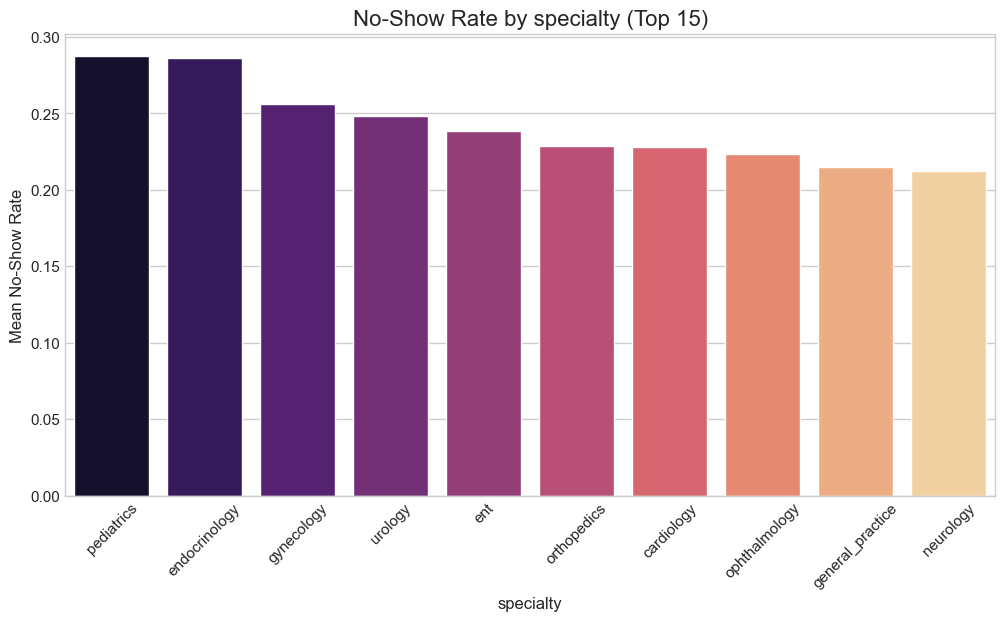

In [51]:
plotting.plot_categorical_noshow_rate(sub_train, 'specialty')

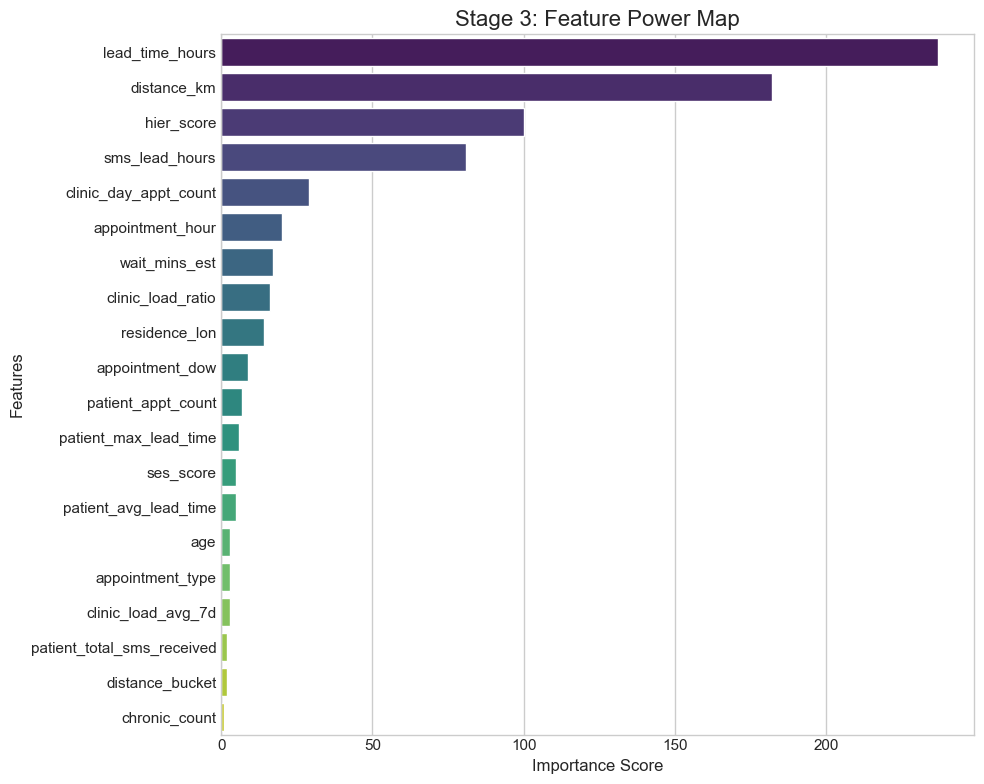

In [ ]:
import lightgbm as lgb

cat_cols = ['booking_channel', 'appointment_type', 'sex', 'specialty_clinic']

for col in cat_cols:
    if col in sub_train.columns:
        sub_train[col] = sub_train[col].astype('category')
        sub_val[col] = sub_val[col].astype('category')

drop_cols = [
    'appointment_id', 'patient_id', 'clinic_id', 
    'appointment_datetime', 'booking_datetime', 
    'label_noshow', 'specialty', 'area_id', 'age_bucket'
]

features = [c for c in sub_train.columns if c not in drop_cols] 

diag_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
diag_model.fit(sub_train[features], sub_train['label_noshow'])

importance_df = pd.DataFrame({
    'feature': features,
    'importance': diag_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# 7. Visualize
plotting.plot_feature_importance(importance_df, title="Stage 3: Feature Power Map")

In [52]:
# Apply demographic proxy based on age_bucket, area, and ses_score
sub_val = feature_engineering.apply_patient_demographic_proxy(sub_train, sub_val)
test_fe = feature_engineering.apply_patient_demographic_proxy(sub_train, test_fe)

# Defensive check for age_bucket conversion
print(f"Age Bucket distribution in Val:\n{sub_val['age_bucket'].value_counts()}")
print(f"Post-Proxy Shape: {sub_val.shape}")

Age Bucket distribution in Val:
age_bucket
5    4966
3    4654
2    4327
4    3913
1    3060
Name: count, dtype: int64
Post-Proxy Shape: (20920, 56)


In [53]:
# Applying the Expansion
print(f"Original shape: {sub_train.shape}")

Original shape: (179080, 55)


In [54]:
print(f"Base shape: {sub_train.shape}")

for df in [sub_train, sub_val, test_fe]:
    df = feature_engineering.create_advanced_interactions(df)

print(f"Shape after Phase 1 (Interactions): {sub_train.shape}")

Base shape: (179080, 55)
Shape after Phase 1 (Interactions): (179080, 60)


In [55]:
sub_val = feature_engineering.apply_multi_level_target_encoding(sub_train, sub_val)
test_fe = feature_engineering.apply_multi_level_target_encoding(sub_train, test_fe)

# Apply to sub_train using its own stats for consistent feature space
sub_train = feature_engineering.apply_multi_level_target_encoding(sub_train, sub_train)

print(f"Sub-train: {sub_train.shape}")
print(f"New TE columns: {[c for c in sub_train.columns if c.startswith('te_')]}")

Sub-train: (179080, 65)
New TE columns: ['te_specialty_day_of_week', 'te_area_id_day_of_week', 'te_specialty_hour', 'te_booking_channel_appointment_type', 'te_sex_specialty']


In [ ]:
# (STD, MAX, Diversity)
sub_train = feature_engineering.create_deep_aggregations(sub_train)
sub_val = feature_engineering.create_deep_aggregations(sub_val)
test_fe = feature_engineering.create_deep_aggregations(test_fe)

print(f"Sub-train: {sub_train.shape}")

Sub-train: (179080, 74)


In [57]:
# Automated expansion via Frequency Counting
sub_train = feature_engineering.generate_bulk_features(sub_train)
sub_val = feature_engineering.generate_bulk_features(sub_val)
test_fe = feature_engineering.generate_bulk_features(test_fe)

print(f"Final Expanded shape: {sub_train.shape}")
display(sub_train.tail(3))

Final Expanded shape: (179080, 79)


,appointment_id,patient_id,clinic_id,specialty,appointment_datetime,booking_datetime,lead_time_hours,appointment_dow,appointment_hour,is_weekend,...,clinic_age_std,clinic_distance_km_mean,pt_spec_nunique,pt_clinic_nunique,pt_area_nunique,specialty_count_freq,clinic_id_count_freq,area_id_count_freq,patient_id_count_freq,hour_count_freq
179077,55149,29999,7,general_practice,2025-06-25 14:00:00,2025-06-23 00:51:24,61.143291,2,14,0,...,22.900779,15.643896,6,7,1,54041,13302,3368,7,8172
179078,121715,30000,1,gynecology,2025-03-07 12:15:00,2025-03-06 15:27:26,20.792530,4,12,0,...,22.990101,13.181166,2,2,1,34487,10060,3094,2,67171
179079,37891,30000,22,general_practice,2025-06-19 10:30:00,2025-06-16 12:48:49,69.686249,3,10,0,...,23.221891,15.189837,2,2,1,54041,8685,3094,2,17923


In [78]:
importlib.reload(config)
from config import STAGE3_OUT

# Ensure directory exists
STAGE3_OUT.mkdir(parents=True, exist_ok=True)

print(f"Saving 'Golden' (79-feature) datasets to: {STAGE3_OUT}")

# Downcast to save space before snapshot
sub_train_79 = data_loader.downcast_memory(sub_train)
sub_val_79 = data_loader.downcast_memory(sub_val)
test_fe_79 = data_loader.downcast_memory(test_fe)

# Save as separate 'golden' files
sub_train_79.to_parquet(STAGE3_OUT / "train_golden_79.parquet", index=False)
sub_val_79.to_parquet(STAGE3_OUT / "val_golden_79.parquet", index=False)
test_fe_79.to_parquet(STAGE3_OUT / "test_golden_79.parquet", index=False)

print(f"Success: 79-feature 'Golden Set' is now persistent.")
print(f"Final Column Count: {len(sub_train_79.columns)}")

Saving 'Golden' (79-feature) datasets to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage3
Success: 79-feature 'Golden Set' is now persistent.
Final Column Count: 79


In [ ]:
print(f"Starting expansion. Current shape: {sub_train.shape}")

# Sıralama: Önce Train'i genişlet, sonra Val ve Test'i Train üzerinden genişlet
sub_train_final = feature_engineering.expand_to_150_plus(sub_train, sub_train)
sub_val_final = feature_engineering.expand_to_150_plus(sub_train, sub_val)
test_fe_final = feature_engineering.expand_to_150_plus(sub_train, test_fe)

print(f"Final Exploded Shapes:")
print(f"Train: {sub_train_final.shape}")
print(f"Val: {sub_val_final.shape}")
print(f"Test: {test_fe_final.shape}")

Starting expansion. Current shape: (179080, 79)
Final Exploded Shapes:
Train: (179080, 166)
Val: (20920, 167)
Test: (80000, 166)


In [77]:
import config
import importlib
importlib.reload(config)
from config import STAGE3_OUT

STAGE3_OUT.mkdir(parents=True, exist_ok=True)

print(f"Saving 167-feature datasets to: {STAGE3_OUT}")

sub_train_final = data_loader.downcast_memory(sub_train_final)
sub_val_final = data_loader.downcast_memory(sub_val_final)
test_fe_final = data_loader.downcast_memory(test_fe_final)

# Parquet Export
sub_train_final.to_parquet(STAGE3_OUT / "train_exploded_167.parquet", index=False)
sub_val_final.to_parquet(STAGE3_OUT / "val_exploded_167.parquet", index=False)
test_fe_final.to_parquet(STAGE3_OUT / "test_exploded_167.parquet", index=False)

print(f"Checkpoint reached: Stage 3 data is now persistent on disk.")
print(f"Final Column Count: {len(sub_train_final.columns)}")

Saving 167-feature datasets to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage3
Checkpoint reached: Stage 3 data is now persistent on disk.
Final Column Count: 167


In [82]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import pandas as pd
import numpy as np

# 1. Load Golden Set (Eğer RAM'de yoksa diskten oku)
# sub_train_79 = pd.read_parquet(STAGE3_OUT / "train_golden_79.parquet")
# sub_val_79 = pd.read_parquet(STAGE3_OUT / "val_golden_79.parquet")

# 2. Prepare Features
drop_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']
features_79 = [c for c in sub_train_79.columns if c not in drop_cols]

# 3. Convert Categoricals
cat_cols_79 = sub_train_79[features_79].select_dtypes(include=['object', 'category', 'str']).columns.tolist()
for col in cat_cols_79:
    sub_train_79[col] = sub_train_79[col].astype('category')
    sub_val_79[col] = sub_val_79[col].astype('category')

lgb_golden = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    is_unbalance=True, # BU ÇOK KRİTİK
    device='gpu',
    random_state=42,
    verbose=-1
)

# 5. Train
print(f"Training with {len(features_79)} Golden features...")
lgb_golden.fit(
    sub_train_79[features_79], sub_train_79['label_noshow'],
    eval_set=[(sub_val_79[features_79], sub_val_79['label_noshow'])],
    eval_metric='auc'
)

# 6. Evaluate
val_preds_79 = lgb_golden.predict_proba(sub_val_79[features_79])[:, 1]
val_classes_79 = lgb_golden.predict(sub_val_79[features_79])

print("\n--- Golden Results (79 Features) ---")
print(f"Validation AUC: {roc_auc_score(sub_val_79['label_noshow'], val_preds_79):.4f}")
print(f"Validation F1: {f1_score(sub_val_79['label_noshow'], val_classes_79):.4f}")
print("\nClassification Report:")
print(classification_report(sub_val_79['label_noshow'], val_classes_79))

Training with 73 Golden features...

--- Golden Results (79 Features) ---
Validation AUC: 0.6924
Validation F1: 0.3859

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15919
           1       0.24      1.00      0.39      5001

    accuracy                           0.24     20920
   macro avg       0.12      0.50      0.19     20920
weighted avg       0.06      0.24      0.09     20920



c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [83]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import pandas as pd
import numpy as np

drop_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']
features = [c for c in sub_train_final.columns if c not in drop_cols]

cat_cols = sub_train_final[features].select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    sub_train_final[col] = sub_train_final[col].astype('category')
    sub_val_final[col] = sub_val_final[col].astype('category')

# 3. Initialize Model
# Using 500 estimators for a quick but meaningful test
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    is_unbalance=True, # BU ÇOK KRİTİK
    device='gpu',
    random_state=42,
    verbose=-1
)

print(f"Training with {len(features)} features...")
lgb_model.fit(
    sub_train_final[features], sub_train_final['label_noshow'],
    eval_set=[(sub_val_final[features], sub_val_final['label_noshow'])],
    eval_metric='auc'
)

val_preds = lgb_model.predict_proba(sub_val_final[features])[:, 1]
val_classes = lgb_model.predict(sub_val_final[features])

auc_score = roc_auc_score(sub_val_final['label_noshow'], val_preds)
f1 = f1_score(sub_val_final['label_noshow'], val_classes)

print("\n--- Baseline Results (167 Features) ---")
print(f"Validation AUC: {auc_score:.4f}")
print(f"Validation F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(sub_val_final['label_noshow'], val_classes))

Training with 161 features...

--- Baseline Results (167 Features) ---
Validation AUC: 0.5997
Validation F1: 0.3859

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15919
           1       0.24      1.00      0.39      5001

    accuracy                           0.24     20920
   macro avg       0.12      0.50      0.19     20920
weighted avg       0.06      0.24      0.09     20920



c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Eren\Desktop\data_league_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

# **STAGE 4**

In [92]:
# 1. Load the 167-feature exploded dataset from Stage 3
print("Loading 167-feature exploded dataset...")
sub_train_167 = pd.read_parquet(STAGE3_OUT / "train_exploded_167.parquet")

Loading 167-feature exploded dataset...


In [93]:
print("\n--- Step 1: Zero Variance Filter ---")
sub_train_filtered, var_report = statistical_tests.drop_zero_variance(sub_train_167)
display(var_report[var_report['Action'] == 'Dropped'].head())


--- Step 1: Zero Variance Filter ---
Variance Check: Dropped 2 zero-variance features.


,Feature,Unique_Values,Action
38,is_cold_start_clinic,1,Dropped
73,pt_area_nunique,1,Dropped


In [94]:
# 3. Correlation Filter
print("\n--- Step 2: Correlation Filter ---")
cols_to_check = [c for c in sub_train_filtered.columns if c not in ['label_noshow', 'appointment_id', 'patient_id', 'clinic_id']]
df_for_corr = sub_train_filtered[cols_to_check]

sub_train_filtered, corr_report, corr_drops = statistical_tests.drop_high_correlation(df_for_corr, threshold=0.90)
sub_train_filtered = sub_train_167.drop(columns=var_report[var_report['Action'] == 'Dropped']['Feature'].tolist() + corr_drops)

print("\nTop Correlated Pairs (Dropped):")
display(corr_report.head(10))


--- Step 2: Correlation Filter ---
Correlation Check: Dropped 58 features (threshold > 0.9).

Top Correlated Pairs (Dropped):


,Feature_1 (Kept),Feature_2 (Dropped),Correlation_Score
0,sms_sent,sms_is_missing,1.0
1,appointment_hour,hour,1.0
2,appointment_dow,day_of_week,1.0
16,te_specialty_day_of_week,combo_te_specialty_day_of_week,1.0
15,te_sex_specialty,combo_te_specialty_sex,1.0
17,te_specialty_hour,combo_te_specialty_hour,1.0
18,te_area_id_day_of_week,combo_te_area_id_day_of_week,1.0
19,te_booking_channel_appointment_type,combo_te_booking_channel_appointment_type,1.0
109,clinic_age_std,stat_clinic_id_age_std,1.0
95,clinic_lead_time_hours_mean,stat_clinic_id_lead_time_hours_mean,1.0


In [95]:
# 4. Information Value (IV) Filter
print("\n--- Step 3: Information Value (IV) Filter ---")
analysis_features = [c for c in sub_train_filtered.columns if c not in ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']]

iv_report, final_features = statistical_tests.calculate_iv_woe(sub_train_filtered, 'label_noshow', analysis_features)

# Hangi özelliğin hangi kategoriye (Useless, Strong, Leakage) girdiğini incele
print("\nInformation Value Report (Head & Tail):")
display(iv_report.head(10))
display(iv_report.tail(5))


--- Step 3: Information Value (IV) Filter ---
IV Analysis: Kept 40 features, Dropped 60 features.

Information Value Report (Head & Tail):


,Feature,IV,Predictive_Power
99,demo_proxy_rate,1.103043,Suspicious (Leakage?)
1,lead_time_hours,0.226684,Medium
43,lead_time_log,0.226684,Medium
40,lead_time_per_age,0.192535,Medium
63,combo_te_area_id_appointment_type,0.180168,Medium
47,te_booking_channel_appointment_type,0.163456,Medium
61,combo_te_specialty_appointment_type,0.160780,Medium
41,lead_time_per_distance,0.143179,Medium
6,appointment_type,0.141135,Medium
9,sms_sent,0.120342,Medium


,Feature,IV,Predictive_Power
54,pt_spec_nunique,2.833392e-04,Useless (Drop)
36,patient_max_lead_time,2.394394e-04,Useless (Drop)
35,patient_avg_lead_time,1.833530e-04,Useless (Drop)
55,pt_clinic_nunique,1.521170e-04,Useless (Drop)
14,sex,3.716436e-07,Useless (Drop)


In [97]:
from config import STAGE4_OUT

leakage_cols = ['demo_proxy_rate', 'lead_time_log']
finel_feature_38 = [f for f in final_features if f not in leakage_cols]

print(f"Removed leakage and redundant features. Final finel_feature_38 count: {len(finel_feature_38)}")

meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']

final_cols_train = [c for c in meta_cols if c in sub_train_filtered.columns] + finel_feature_38
final_cols_val = [c for c in meta_cols if c in sub_val_final.columns] + finel_feature_38
final_cols_test = [c for c in meta_cols if c in test_fe_final.columns] + finel_feature_38

sub_train_finel_feature_38 = sub_train_filtered[final_cols_train]
sub_val_finel_feature_38 = sub_val_final[final_cols_val]
test_fe_finel_feature_38 = test_fe_final[final_cols_test]

STAGE4_OUT.mkdir(parents=True, exist_ok=True)
print(f"Saving {len(finel_feature_38)}-feature finel_feature_38 datasets to: {STAGE4_OUT}")

sub_train_finel_feature_38.to_parquet(STAGE4_OUT / "train_finel_feature_38.parquet", index=False)
sub_val_finel_feature_38.to_parquet(STAGE4_OUT / "val_finel_feature_38.parquet", index=False)
test_fe_finel_feature_38.to_parquet(STAGE4_OUT / "test_finel_feature_38.parquet", index=False)

print("Stage 4 definitively complete. Data is pure and secure.")

Removed leakage and redundant features. Final finel_feature_38 count: 38
Saving 38-feature finel_feature_38 datasets to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage4
Stage 4 definitively complete. Data is pure and secure.


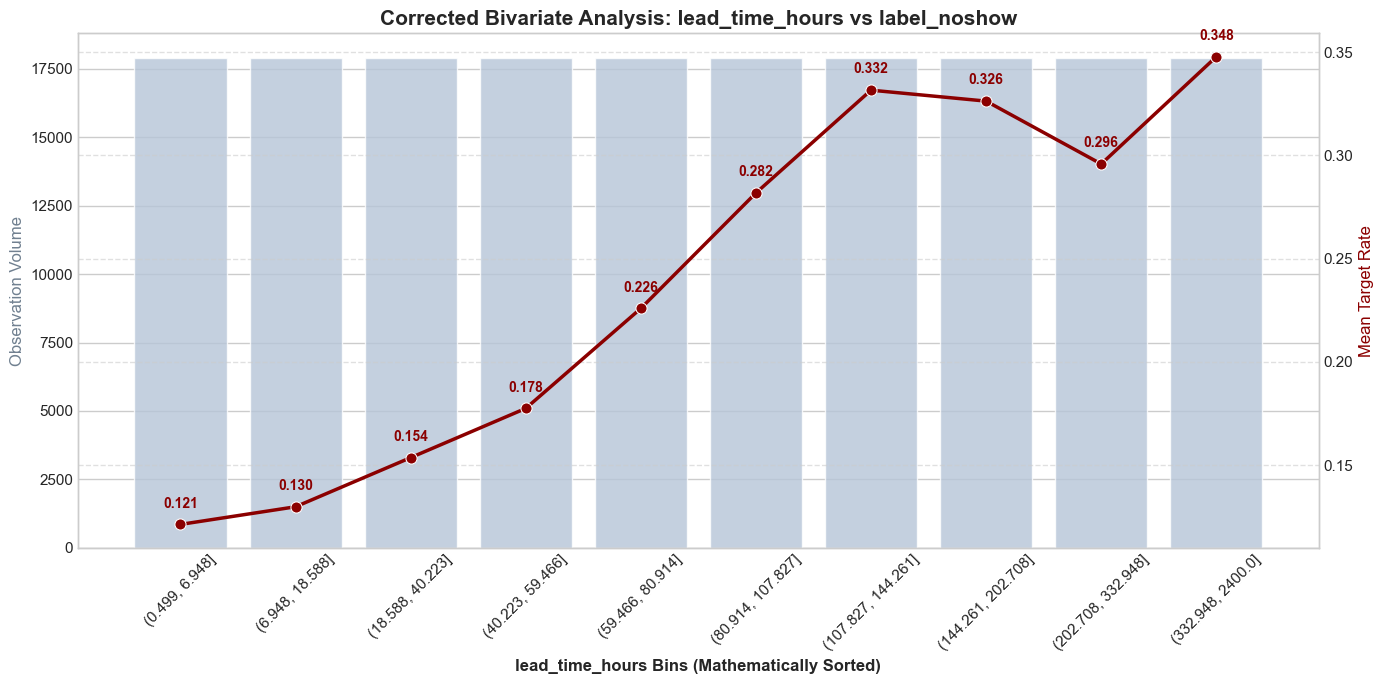

In [108]:
plotting.plot_bivariate_target_rate(df=sub_train_finel_feature_38, feature='lead_time_hours', target='label_noshow')

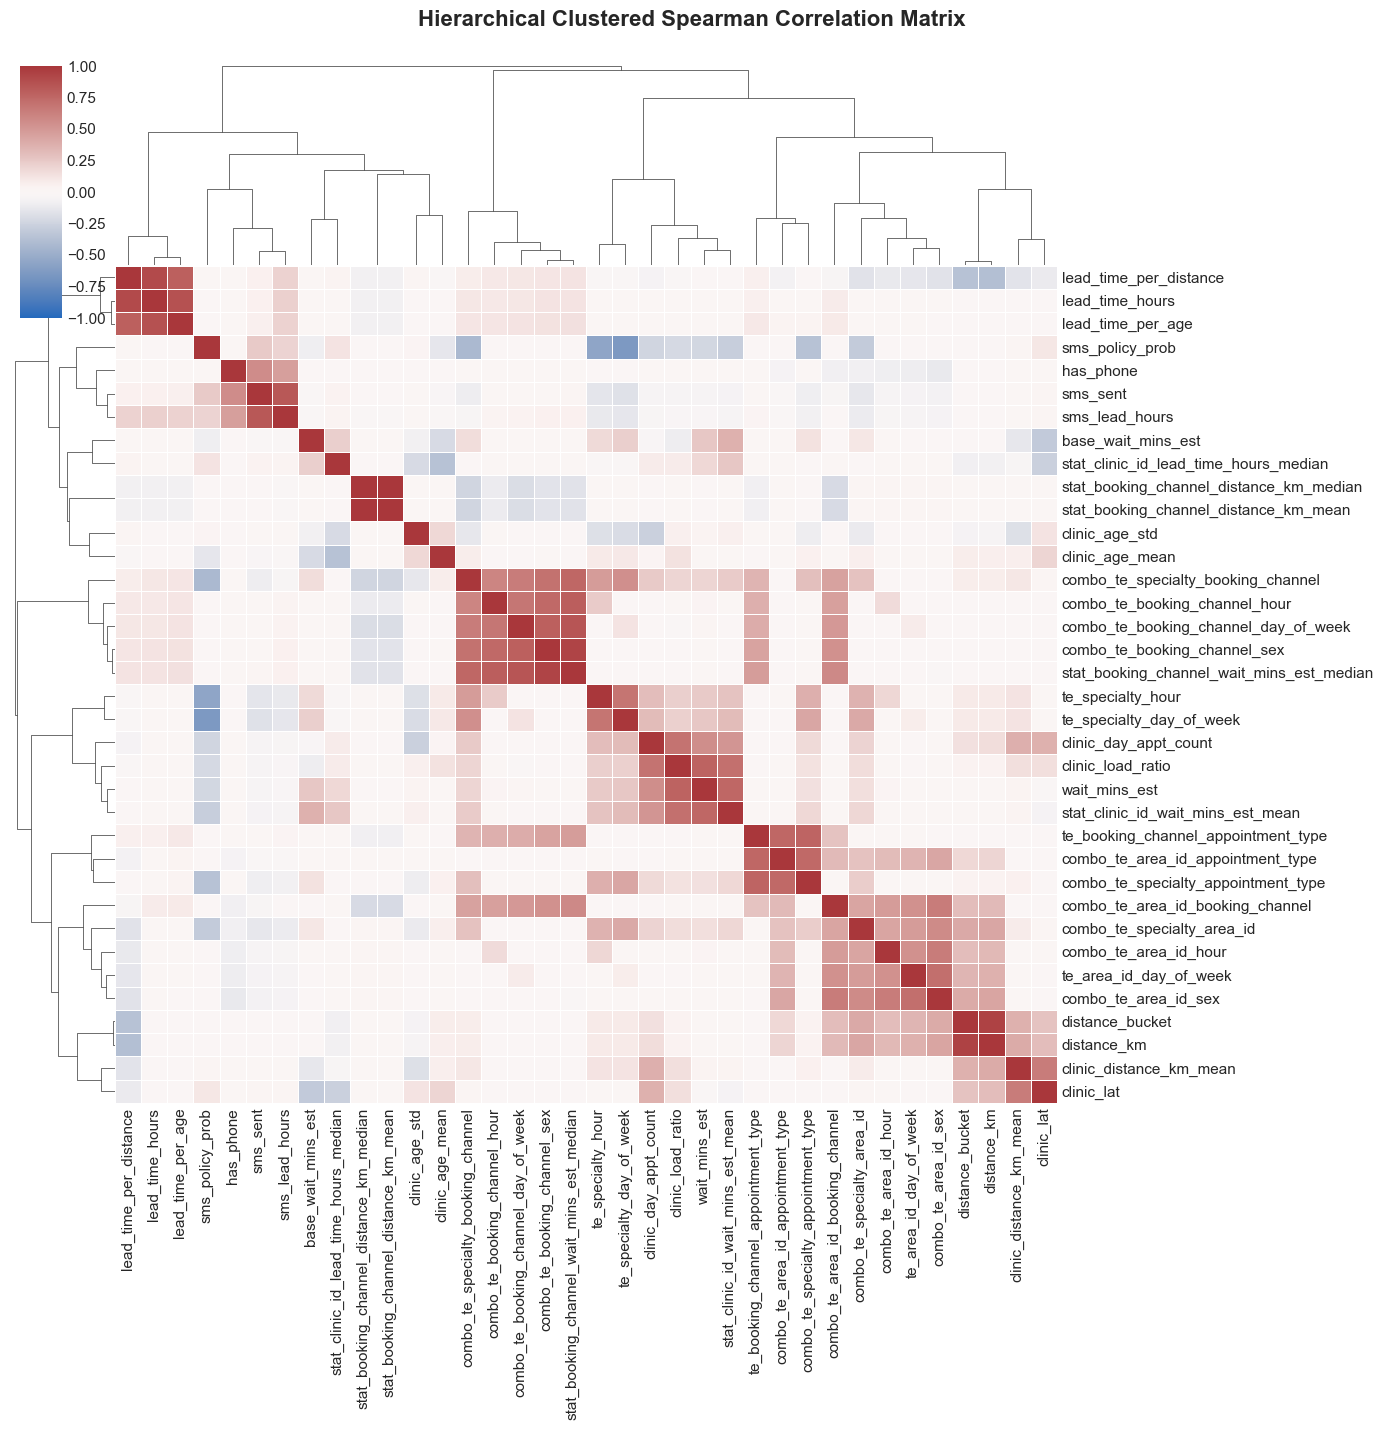

In [101]:
plotting.plot_clustered_correlation(df=sub_train_finel_feature_38, features_list=finel_feature_38)

In [111]:
from config import STAGE4_OUT

print("--- Analyzing Multicollinearity on Training Data ---")
pure_features = statistical_tests.remove_collinear_features(
    df=sub_train_finel_feature_38, 
    target_col='label_noshow', 
    threshold=0.85
)

meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']

final_cols_train = [c for c in meta_cols if c in sub_train_finel_feature_38.columns] + pure_features
final_cols_val = [c for c in meta_cols if c in sub_val_finel_feature_38.columns] + pure_features
final_cols_test = [c for c in meta_cols if c in test_fe_finel_feature_38.columns] + pure_features

--- Analyzing Multicollinearity on Training Data ---
Initial independent feature count: 39
Features eliminated due to redundancy (|r| > 0.85): 4
Remaining pure feature count: 35

Eliminated Features:
 - combo_te_booking_channel_sex
 - combo_te_specialty_appointment_type
 - distance_km
 - stat_booking_channel_distance_km_median


In [115]:
meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']

pure_features_clean = [f for f in pure_features if f not in meta_cols]

print(f"Original pure_features count: {len(pure_features)}")
print(f"Cleaned pure_features count (metadata explicitly excluded): {len(pure_features_clean)}")

final_cols_train = [c for c in meta_cols if c in sub_train_finel_feature_38.columns] + pure_features_clean
final_cols_val = [c for c in meta_cols if c in sub_val_finel_feature_38.columns] + pure_features_clean
final_cols_test = [c for c in meta_cols if c in test_fe_finel_feature_38.columns] + pure_features_clean

sub_train_pure = sub_train_finel_feature_38[final_cols_train]
sub_val_pure = sub_val_finel_feature_38[final_cols_val]
test_fe_pure = test_fe_finel_feature_38[final_cols_test]

STAGE4_OUT.mkdir(parents=True, exist_ok=True)

Original pure_features count: 35
Cleaned pure_features count (metadata explicitly excluded): 32


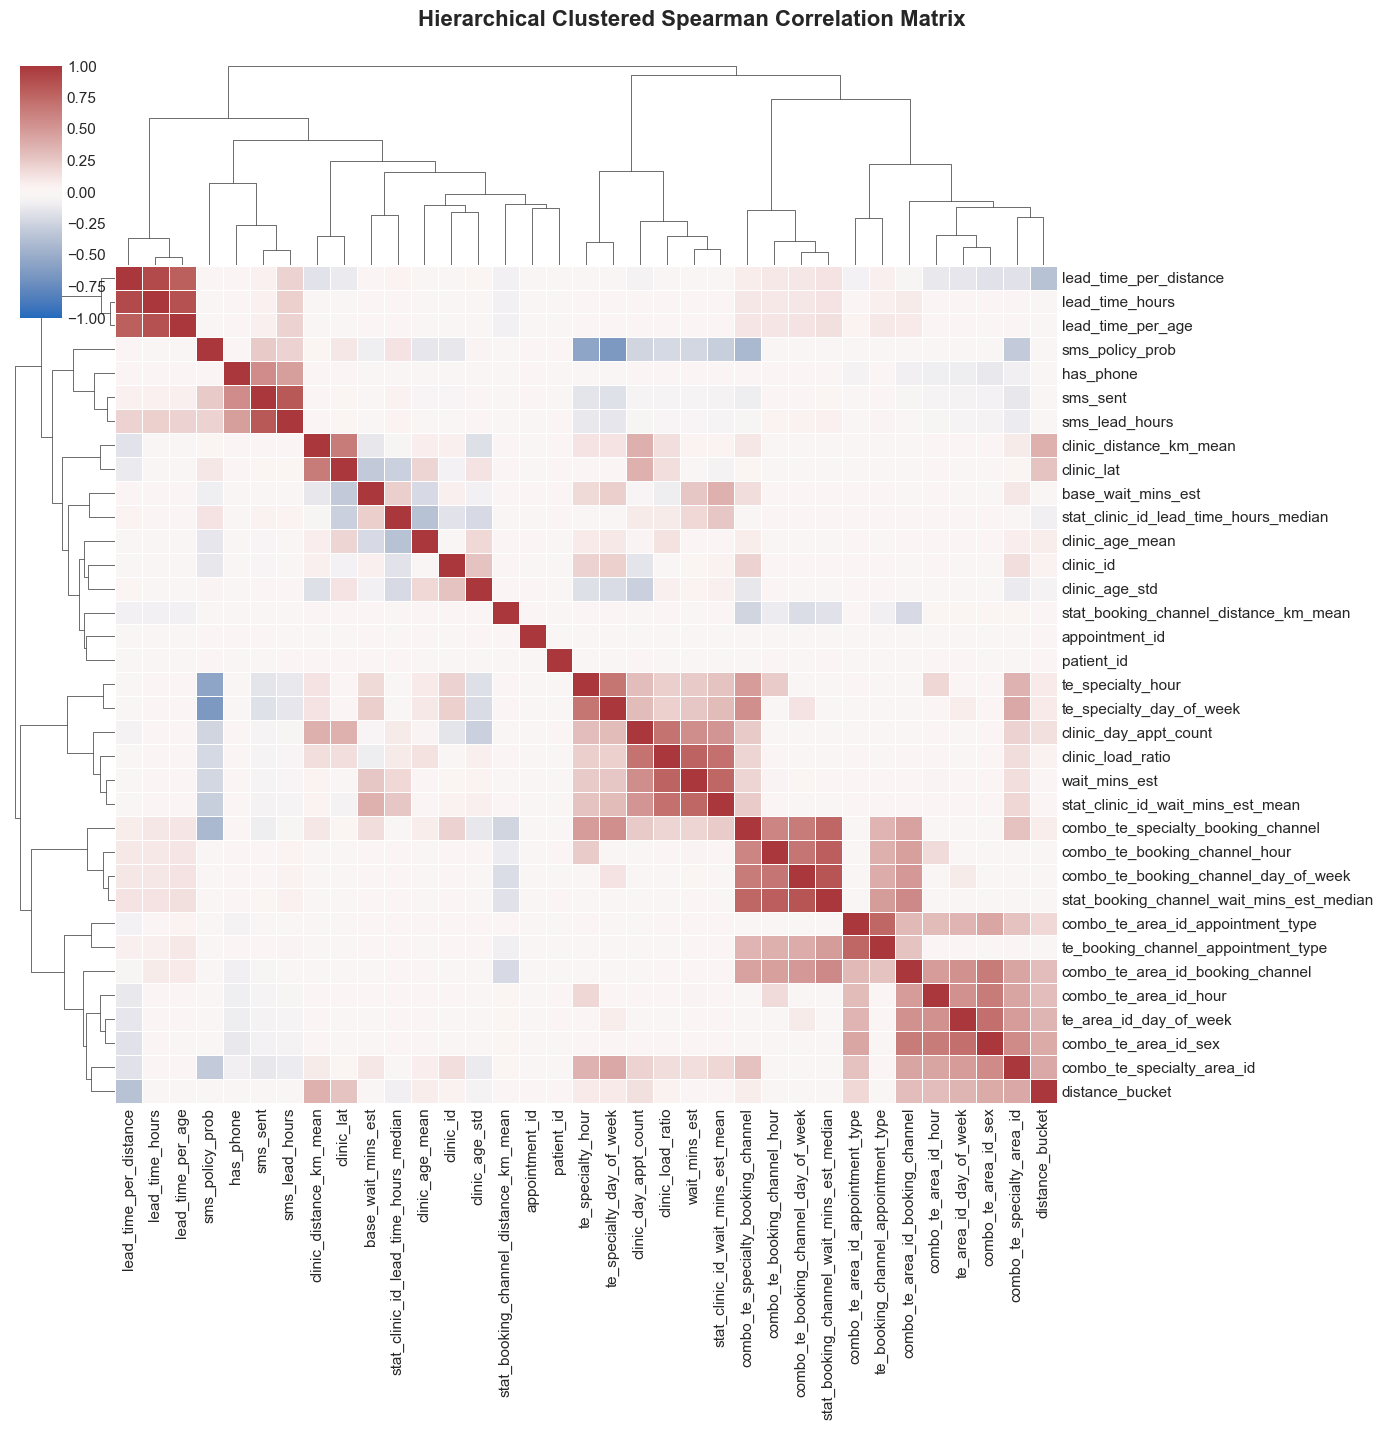

In [116]:
plotting.plot_clustered_correlation(
    df=sub_train_pure, 
    features_list=pure_features
)

In [119]:
STAGE4_OUT.mkdir(parents=True, exist_ok=True)

sub_train_pure.to_parquet(STAGE4_OUT / "train_32.parquet", index=False)
sub_val_pure.to_parquet(STAGE4_OUT / "val_32.parquet", index=False)
test_fe_pure.to_parquet(STAGE4_OUT / "test_32.parquet", index=False)

Total pure features to plot: 32
Generating 6 sequential plots for rigorous statistical inspection...


--- Executing Batch 1/6: Features 1 to 6 ---


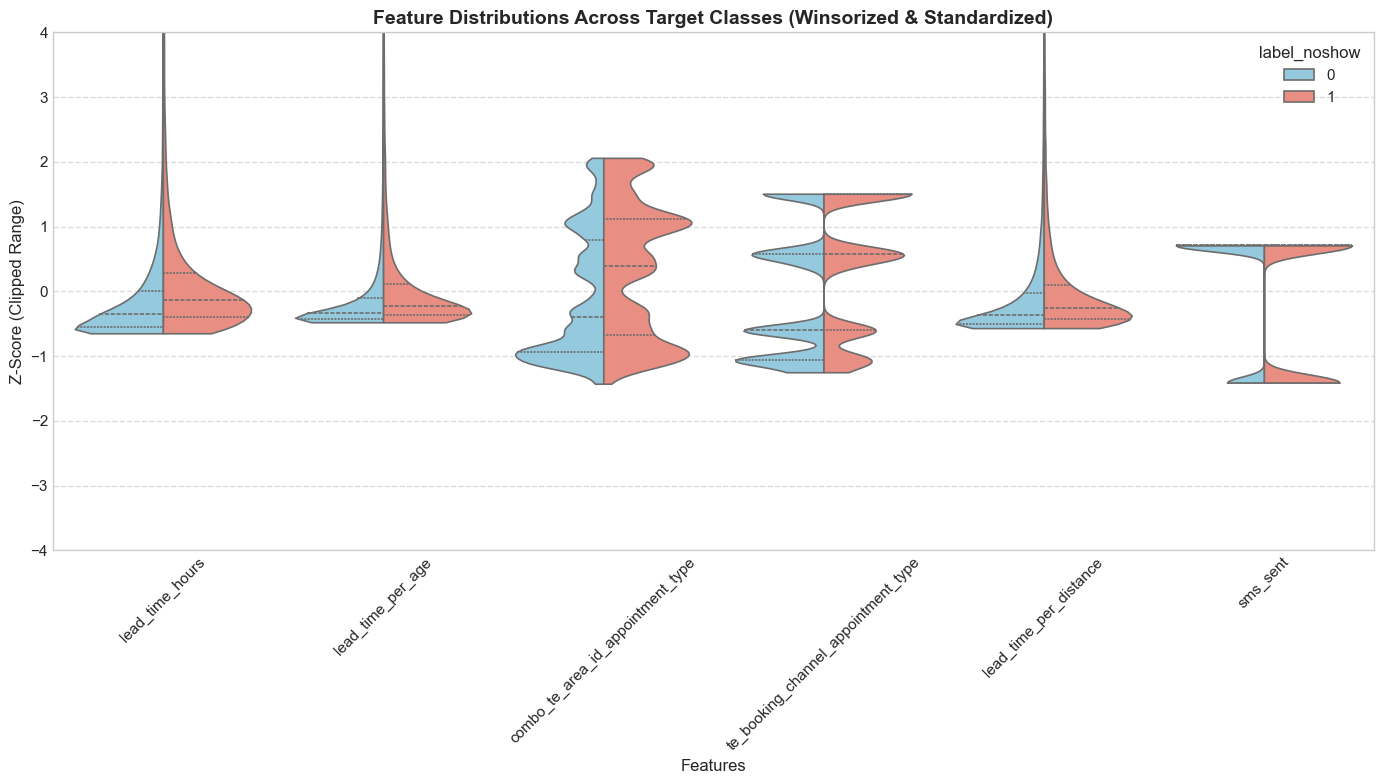


--- Executing Batch 2/6: Features 7 to 12 ---


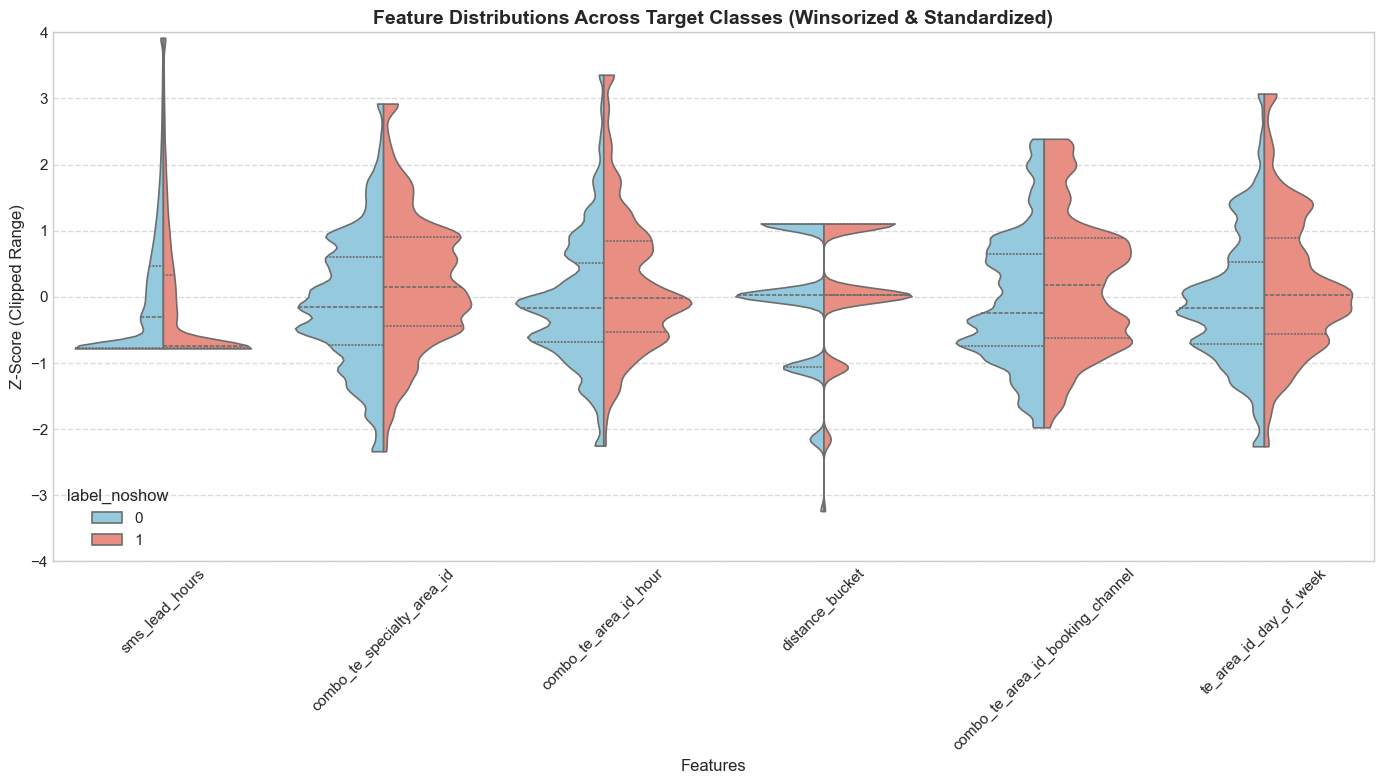


--- Executing Batch 3/6: Features 13 to 18 ---


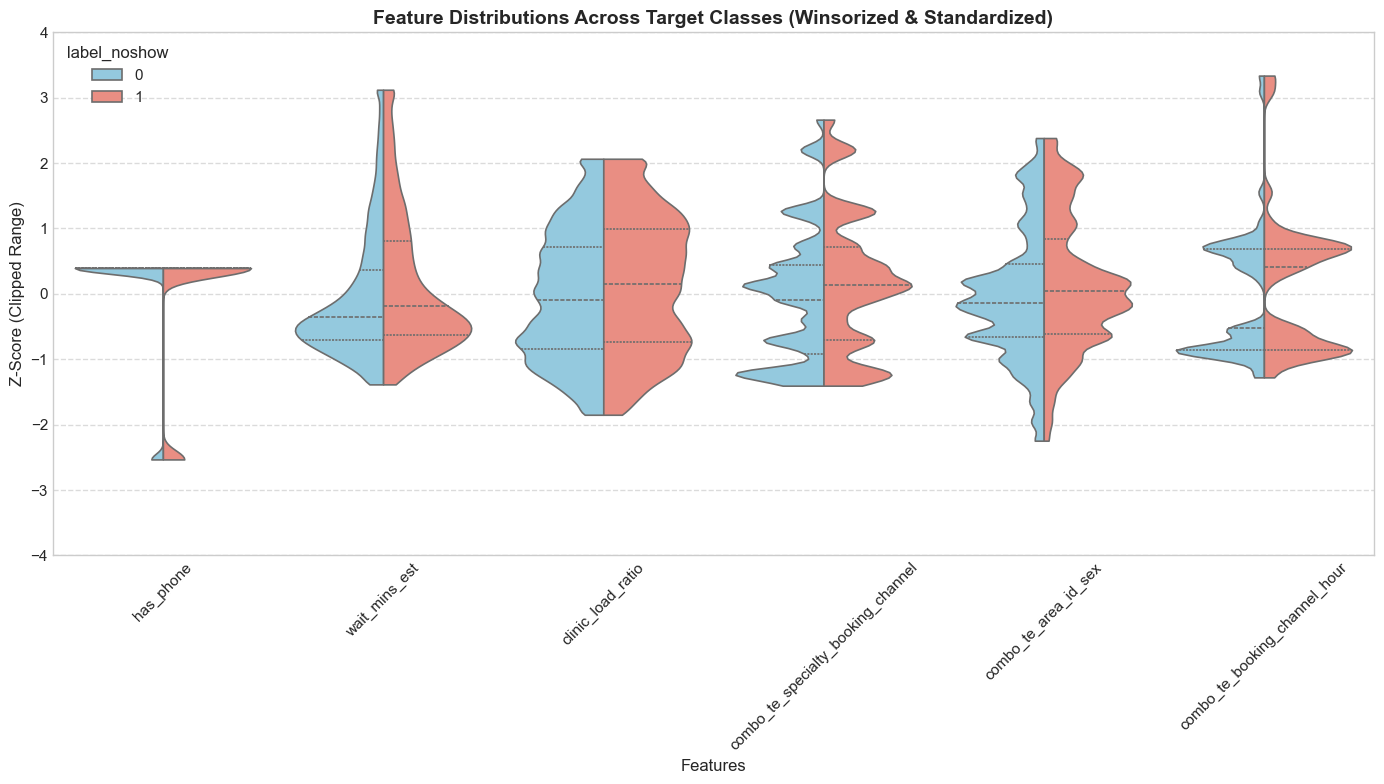


--- Executing Batch 4/6: Features 19 to 24 ---


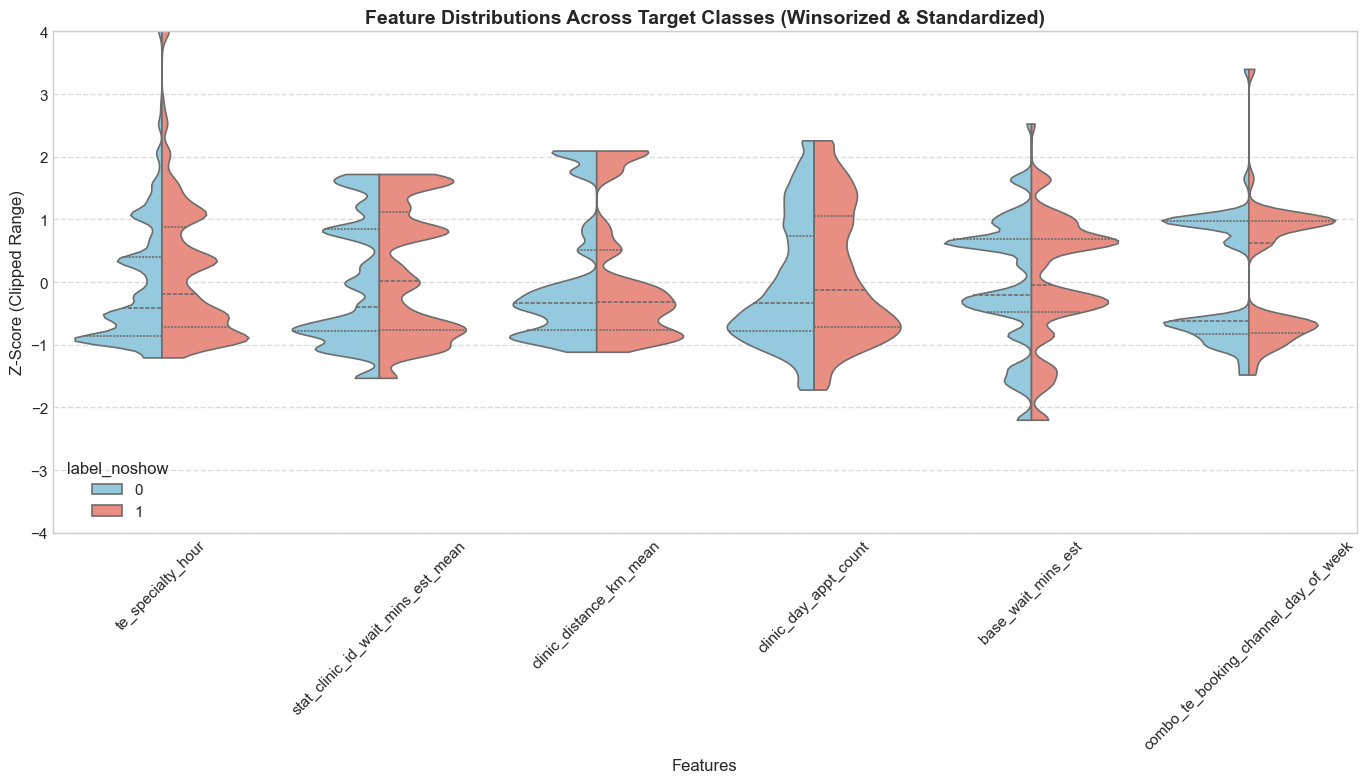


--- Executing Batch 5/6: Features 25 to 30 ---


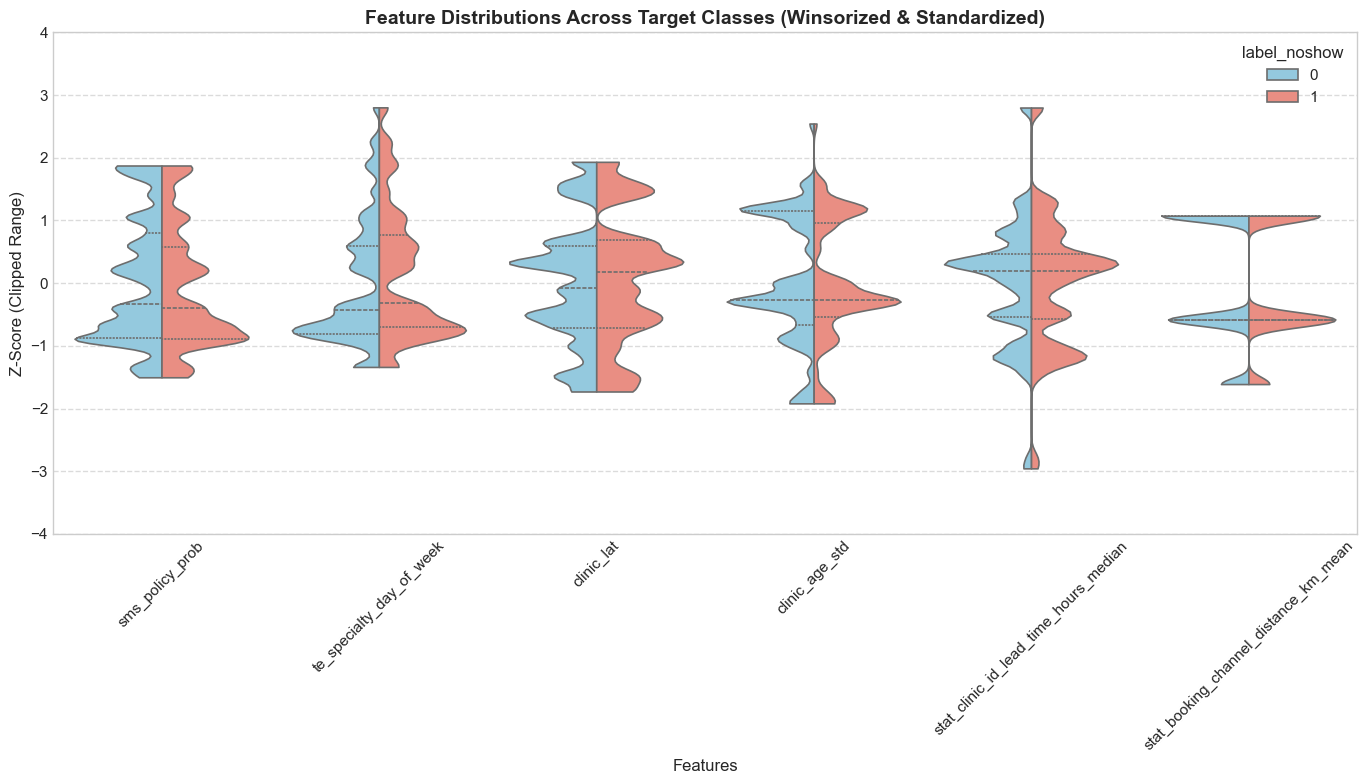


--- Executing Batch 6/6: Features 31 to 32 ---


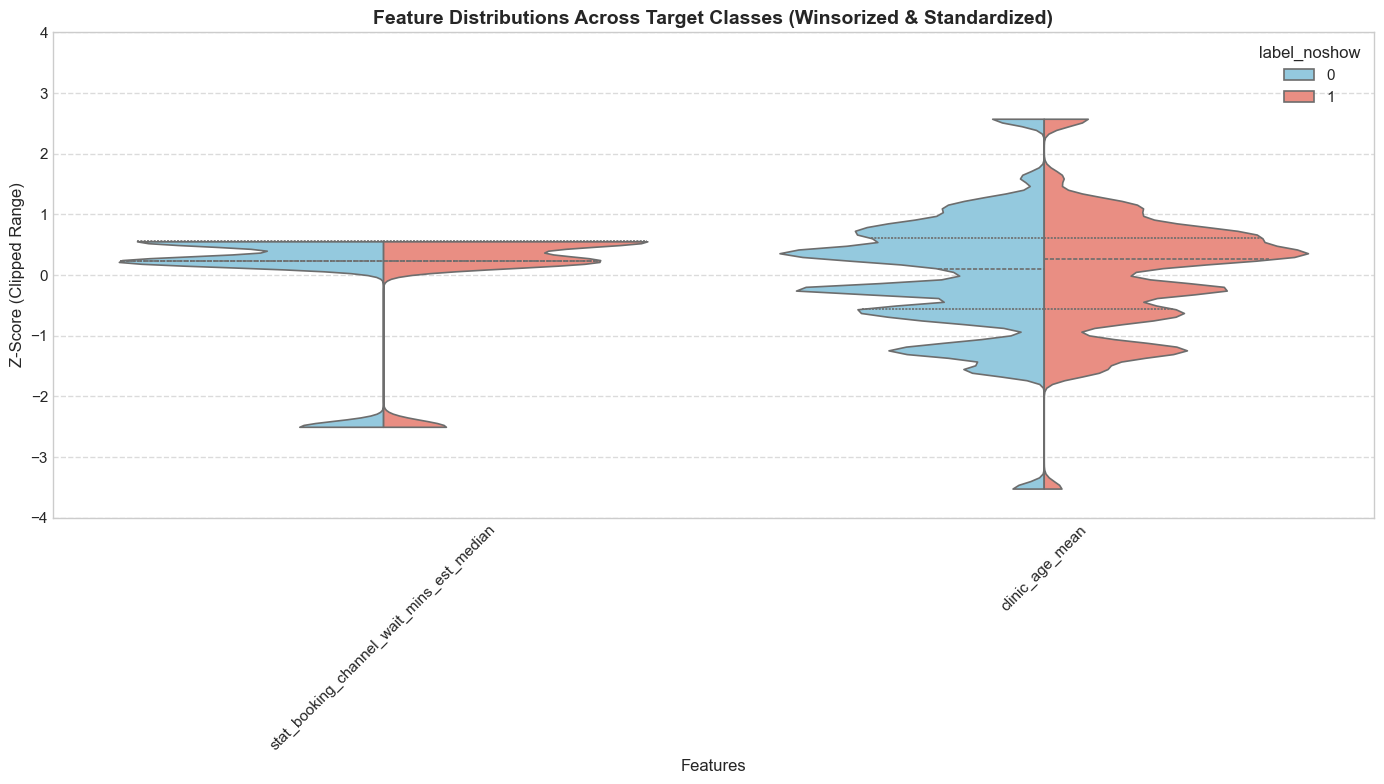

In [122]:
import math

meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']
pure_features_to_plot = [col for col in sub_train_pure.columns if col not in meta_cols]

batch_size = 6
num_batches = math.ceil(len(pure_features_to_plot) / batch_size)

print(f"Total pure features to plot: {len(pure_features_to_plot)}")
print(f"Generating {num_batches} sequential plots for rigorous statistical inspection...\n")

for i in range(num_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(pure_features_to_plot))
    current_batch = pure_features_to_plot[start_idx:end_idx]
    
    print(f"\n--- Executing Batch {i+1}/{num_batches}: Features {start_idx+1} to {end_idx} ---")
    
    plotting.plot_feature_target_distribution(
        df=sub_train_pure, 
        features=current_batch, 
        target='label_noshow'
    )

In [125]:
meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']

pure_features_to_test = [col for col in sub_train_pure.columns if col not in meta_cols]

print(f"Total pure features queued for Univariate AUC evaluation: {len(pure_features_to_test)}\n")

auc_ranking_df = metrics.evaluate_univariate_auc(
    df=sub_train_pure, 
    features=pure_features_to_test, 
    target='label_noshow'
)

display(auc_ranking_df)

Total pure features queued for Univariate AUC evaluation: 32

Executing Univariate AUC evaluation for 32 features...

--- Top 10 Strongest Features ---
                            Feature  Univariate_AUC
                    lead_time_hours        0.627438
  combo_te_area_id_appointment_type        0.621160
                  lead_time_per_age        0.619298
te_booking_channel_appointment_type        0.611927
             lead_time_per_distance        0.588421
         combo_te_specialty_area_id        0.586440
                           sms_sent        0.583595
              combo_te_area_id_hour        0.579536
   combo_te_area_id_booking_channel        0.572390
             te_area_id_day_of_week        0.568503

--- Top 5 Weakest Features ---
                              Feature  Univariate_AUC
                      clinic_age_mean        0.514168
stat_booking_channel_distance_km_mean        0.513896
                   base_wait_mins_est        0.505896
                       clini

,Feature,Univariate_AUC
0,lead_time_hours,0.627438
1,combo_te_area_id_appointment_type,0.621160
2,lead_time_per_age,0.619298
3,te_booking_channel_appointment_type,0.611927
4,lead_time_per_distance,0.588421
5,combo_te_specialty_area_id,0.586440
6,sms_sent,0.583595
7,combo_te_area_id_hour,0.579536
8,combo_te_area_id_booking_channel,0.572390
9,te_area_id_day_of_week,0.568503


In [126]:
from config import STAGE4_OUT

AUC_THRESHOLD = 0.515

strong_features = auc_ranking_df[auc_ranking_df['Univariate_AUC'] >= AUC_THRESHOLD]['Feature'].tolist()
dead_features = auc_ranking_df[auc_ranking_df['Univariate_AUC'] < AUC_THRESHOLD]['Feature'].tolist()

print(f"--- Scientific Elimination based on Univariate AUC < {AUC_THRESHOLD} ---")
print(f"Features Retained (Signal): {len(strong_features)}")
print(f"Features Eliminated (Noise): {len(dead_features)}\n")

print("List of Eliminated Features:")
for f in dead_features:
    print(f" - {f}")

--- Scientific Elimination based on Univariate AUC < 0.515 ---
Features Retained (Signal): 27
Features Eliminated (Noise): 5

List of Eliminated Features:
 - clinic_age_mean
 - stat_booking_channel_distance_km_mean
 - base_wait_mins_est
 - clinic_age_std
 - stat_clinic_id_lead_time_hours_median


In [127]:
meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']

final_cols_train = [c for c in meta_cols if c in sub_train_pure.columns] + strong_features
final_cols_val = [c for c in meta_cols if c in sub_val_pure.columns] + strong_features
final_cols_test = [c for c in meta_cols if c in test_fe_pure.columns] + strong_features

sub_train_final = sub_train_pure[final_cols_train]
sub_val_final = sub_val_pure[final_cols_val]
test_fe_final = test_fe_pure[final_cols_test]

STAGE4_OUT.mkdir(parents=True, exist_ok=True)

sub_train_final.to_parquet(STAGE4_OUT / "train_27.parquet", index=False)
sub_val_final.to_parquet(STAGE4_OUT / "val_27.parquet", index=False)
test_fe_final.to_parquet(STAGE4_OUT / "test_27.parquet", index=False)

print(f"\nOptimization complete. The highly predictive datasets are saved to: {STAGE4_OUT}")


Optimization complete. The highly predictive datasets are saved to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage4


In [134]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from config import STAGE4_OUT

# 1. Loading the optimal training dataset
df_train = pd.read_parquet(STAGE4_OUT / "train_27.parquet")
target_col = 'label_noshow'
meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']
features = [c for c in df_train.columns if c not in meta_cols]

X = df_train[features]
y = df_train[target_col]

# 2. Setup Stratified 5-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Parameters (Based on our last optimized run)
params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 48,
    'max_depth': -1,
    'is_unbalance': True,
    'min_data_in_leaf': 100,
    'lambda_l1': 0.5,
    'lambda_l2': 0.5,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'device': 'gpu'
}

oof_pr_auc_scores = []
models = []

print(f"Starting Stratified {n_splits}-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    lgb_train = lgb.Dataset(X_train_fold, label=y_train_fold)
    lgb_val = lgb.Dataset(X_val_fold, label=y_val_fold, reference=lgb_train)
    
    model = lgb.train(
        params=params,
        train_set=lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    val_preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    fold_pr_auc = average_precision_score(y_val_fold, val_preds)
    oof_pr_auc_scores.append(fold_pr_auc)
    models.append(model)
    
    print(f"Fold {fold+1} | PR-AUC: {fold_pr_auc:.4f} | Best Iteration: {model.best_iteration}")

# 4. Global Performance Metrics
mean_pr_auc = np.mean(oof_pr_auc_scores)
std_pr_auc = np.std(oof_pr_auc_scores)

print(f"\n--- CV Performance Analysis ---")
print(f"Mean OOF PR-AUC: {mean_pr_auc:.4f} (+/- {std_pr_auc:.4f})")

Starting Stratified 5-Fold Cross-Validation...

Fold 1 | PR-AUC: 0.5079 | Best Iteration: 420
Fold 2 | PR-AUC: 0.5069 | Best Iteration: 589
Fold 3 | PR-AUC: 0.5136 | Best Iteration: 568
Fold 4 | PR-AUC: 0.5008 | Best Iteration: 420
Fold 5 | PR-AUC: 0.5105 | Best Iteration: 434

--- CV Performance Analysis ---
Mean OOF PR-AUC: 0.5080 (+/- 0.0042)


In [138]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from config import STAGE4_OUT

# 1. Loading the optimal training dataset
df_train = pd.read_parquet(STAGE4_OUT / "train_27.parquet")
target_col = 'label_noshow'
meta_cols = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow', 'appointment_datetime', 'booking_datetime']
features = [c for c in df_train.columns if c not in meta_cols]

X = df_train[features]
y = df_train[target_col]

# 2. Setup Stratified 5-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Optimized CatBoost Parameters for PR-AUC
# scale_pos_weight is set to 3.0 assuming ~25% no-show rate
cat_params = {
    'iterations': 2000,
    'learning_rate': 0.02,
    'depth': 7,                          # Slightly deeper to capture interactions
    'l2_leaf_reg': 10,                   # Stronger L2 regularization
    'min_data_in_leaf': 50,              # Prevent overfitting on micro-patterns
    'random_strength': 1,                # Add randomness to scoring splits
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'eval_metric': 'PRAUC',
    'random_seed': 42,
    'scale_pos_weight': 3.0,             # Fine-tuned class weighting
    'early_stopping_rounds': 100,
    'task_type': 'GPU',
    'verbose': False                     # Set to False to keep console clean during folds
}

oof_pr_auc_scores = []
cat_models = []

print(f"Starting Optimized CatBoost Stratified {n_splits}-Fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    train_pool = Pool(X_train_fold, y_train_fold)
    val_pool = Pool(X_val_fold, y_val_fold)
    
    model = CatBoostClassifier(**cat_params)
    model.fit(train_pool, eval_set=val_pool)
    
    val_preds = model.predict_proba(X_val_fold)[:, 1]
    fold_pr_auc = average_precision_score(y_val_fold, val_preds)
    
    oof_pr_auc_scores.append(fold_pr_auc)
    cat_models.append(model)
    
    print(f"Fold {fold+1} | PR-AUC: {fold_pr_auc:.4f} | Best Iteration: {model.get_best_iteration()}")

# 4. Global Performance Analysis
mean_pr_auc = np.mean(oof_pr_auc_scores)
std_pr_auc = np.std(oof_pr_auc_scores)

print(f"\n--- CatBoost CV Performance Analysis ---")
print(f"Mean OOF PR-AUC: {mean_pr_auc:.4f} (+/- {std_pr_auc:.4f})")

Starting Optimized CatBoost Stratified 5-Fold CV...



Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Fold 1 | PR-AUC: 0.5101 | Best Iteration: 684


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Fold 2 | PR-AUC: 0.5067 | Best Iteration: 732


...

Fold 3 | PR-AUC: 0.5139 | Best Iteration: 780


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Fold 4 | PR-AUC: 0.5004 | Best Iteration: 648


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Fold 5 | PR-AUC: 0.5115 | Best Iteration: 612

--- CatBoost CV Performance Analysis ---
Mean OOF PR-AUC: 0.5085 (+/- 0.0047)


# **STAGE 5**